# Лабораторная работа №4 — Байесовская сеть

#### Работу выполнил студент 303 группы Ефимов Сергей

### Тема:
##### Построение и обучение Байесовской сети для моделирования зависимостей между признаками и прогнозирования целевой переменной.

### Датасет:
##### https://www.kaggle.com/code/ademox02/bayesian-networks

### Цель работы:
#### Познакомиться с принципами построения Байесовских сетей, понять их структуру и способ представления вероятностных зависимостей между переменными, научиться обучать сеть на реальных данных и использовать её для инференса (прогнозирования целевой переменной по наблюдениям).

### Задачи

1. Выбрать датасет.
2. Загрузка и подготовка данных.
3. Провести базовый анализ: количество признаков, их типы (числовые/категориальные), наличие пропусков.
4. Выбрать подмножество категориальных или дискретизируемых числовых признаков, отражающих принципиально важные для предсказания таргета знания (таргет также выбрать самостоятельно).
5. Дискретизировать числовые признаки (если хотим использовать как входные данные, а также дискретизировать таргет, если он не является категорией).
6. Определить целевую переменную.
7. Построение структуры Байесовской сети.
8. Определить логические зависимости между признаками (ориентированные рёбра).
9. Составить структуру графа (DAG), отражающую причинно-следственные связи.
10. Реализовать модель с помощью библиотеки PyAgrum или pgmpy:
11. Визуализировать структуру сети.
12. Обучение параметров сети\
    a. Обучить условные распределения (CPD) на данных с помощью метода максимального правдоподобия или байесовской оценки.\
    b. Проверить корректность полученных таблиц вероятностей (чтобы не было абсурдных значений)
13. Инференс и анализ\
    a. Провести вероятностный вывод (inference): рассчитать вероятности целевой переменной при заданных наблюдениях.\
    b. Сравнить результаты при разных сценариях (взять например логически противоположные наблюдения.

### Данные датасета

sex – пол

age – возраст

urbanization – уровень урбанизации

education – образование

geographic_area – географическое расположение

allergy – аллергия на дым

smoke – курит ли человек

sedentary – малоподвижный образ жизни или нет

### Исследование датасета

In [1]:
import pandas as pd

data = pd.read_excel("data/data_bn.xlsx")


print("Количество признаков:", data.shape[1])
print("Имена признаков:", data.columns.tolist())

print("\nТипы признаков:\n", data.dtypes)

print("\nПропуски в данных:\n", data.isnull().sum())

categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nСтатистика категориальных признаков:\n", data[categorical_features].describe())


Количество признаков: 9
Имена признаков: ['sex', 'age', 'urbanization', 'education', 'geographic_area', 'allergy', 'smoke', 'sedentary', 'asthma']

Типы признаков:
 sex                object
age                object
urbanization       object
education          object
geographic_area    object
allergy            object
smoke              object
sedentary          object
asthma             object
dtype: object

Пропуски в данных:
 sex                0
age                0
urbanization       0
education          0
geographic_area    0
allergy            0
smoke              0
sedentary          0
asthma             0
dtype: int64

Статистика категориальных признаков:
            sex    age urbanization education geographic_area allergy smoke  \
count     2755   2755         2755      2755            2755    2755  2755   
unique       2      3            3         2               3       2     2   
top     female  adult       medium       low           north      no    no   
freq      146

### Подготовка данных

In [2]:
from sklearn.preprocessing import LabelEncoder

all_features = data.columns.tolist()

encoders = {}

for col in all_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

print(data.head())

for col in all_features:
    print(f"{col}: {list(encoders[col].classes_)}")

   sex  age  urbanization  education  geographic_area  allergy  smoke  \
0    1    0             1          1                2        1      1   
1    0    1             1          1                2        1      0   
2    0    0             0          0                0        0      0   
3    1    0             2          1                2        1      0   
4    0    0             1          0                1        0      0   

   sedentary  asthma  
0          1       1  
1          1       1  
2          1       1  
3          0       0  
4          0       0  
sex: ['female', 'male']
age: ['adult', 'old', 'young']
urbanization: ['high', 'low', 'medium']
education: ['high', 'low']
geographic_area: ['centre', 'north', 'south/islands']
allergy: ['no', 'yes']
smoke: ['no', 'yes']
sedentary: ['no', 'yes']
asthma: ['no', 'yes']


### Определение зависимостей признака и основного параметра

#### Целевая переменная -- asthma. Т.к. все данные влияют на курение или риск астмы, курение также приводит в повышению шанса астмы

sex -> smoke (пол влияет на вероятность курения)

age -> smoke (возраст влияет на курение)

age -> sedentary (влияет на уровень активности человека)

urbanization -> smoke (городская среда влияет на частоту курящих)

education -> smoke (образование влияет на шанс курения)

geographic_area -> education (география влияет на уровень образования)

allergy -> asthma (наличие аллергий повышает риск астмы)

smoke -> asthma (курение напрямую влияет на астму)

sedentary -> asthma (подвижность влияет на риск астмы)

geographic_area -> asthma (территория может влиять на астму)

### Построение DAG и обучение параметров сети

C:\Users\Sergey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'sex': 'N', 'age': 'N', 'urbanization': 'N', 'education': 'N', 'geographic_area': 'N', 'allergy': 'N', 'smoke': 'N', 'sedentary': 'N', 'asthma': 'N'}


Edges in DAG:
 [('sex', 'smoke'), ('smoke', 'asthma'), ('age', 'smoke'), ('age', 'sedentary'), ('sedentary', 'asthma'), ('urbanization', 'smoke'), ('education', 'smoke'), ('geographic_area', 'education'), ('geographic_area', 'asthma'), ('allergy', 'asthma')]


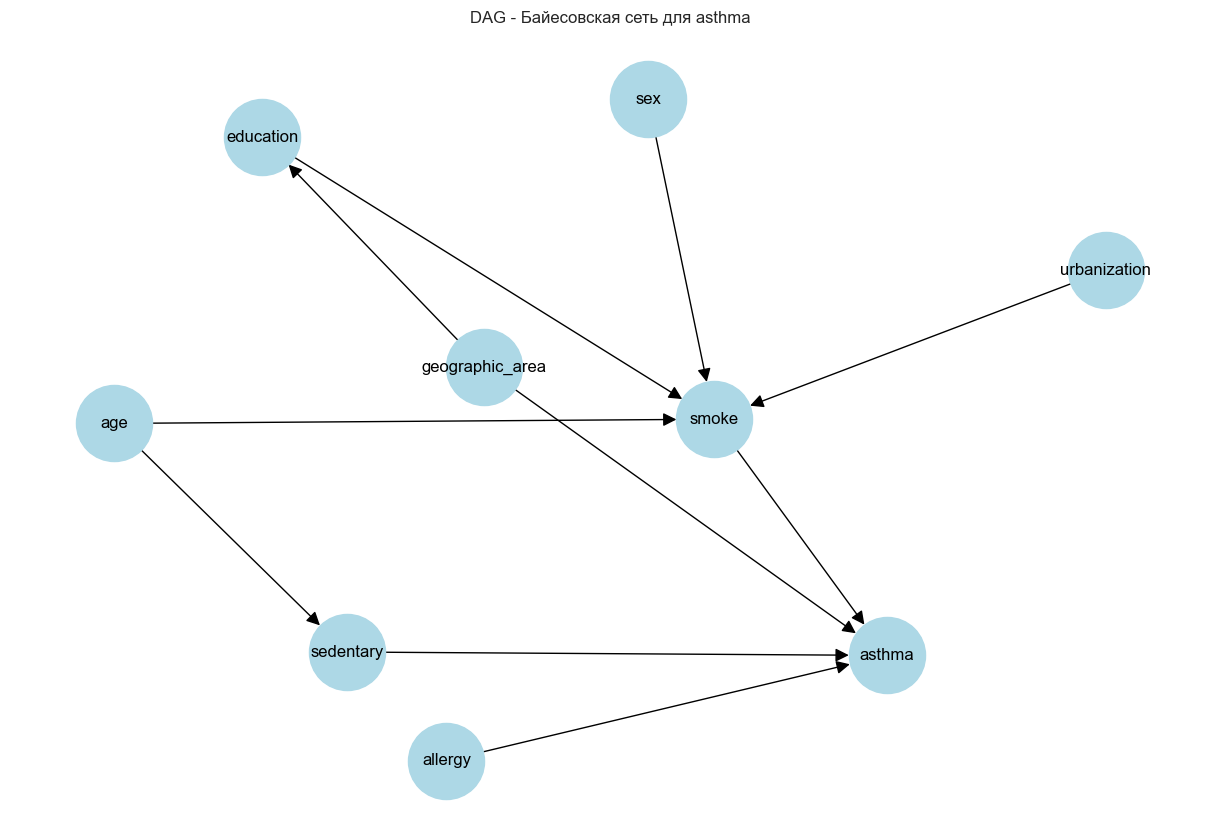

In [3]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
import matplotlib.pyplot as plt
import networkx as nx

model = DiscreteBayesianNetwork([
    ('sex', 'smoke'),
    ('age', 'smoke'),
    ('age', 'sedentary'),
    ('urbanization', 'smoke'),
    ('education', 'smoke'),
    ('geographic_area', 'education'),
    ('allergy', 'asthma'),
    ('smoke', 'asthma'),
    ('sedentary', 'asthma'),
    ('geographic_area', 'asthma')
])

model.fit(data, estimator=MaximumLikelihoodEstimator)

print("Edges in DAG:\n", model.edges())

G = nx.DiGraph()
G.add_edges_from(model.edges())

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', arrowsize=20)
plt.title("DAG - Байесовская сеть для asthma")
plt.show()

### Просмотр и проверка CPD

In [5]:
import numpy as np

for node in model.nodes():
    print(f"\nCPD for {node}:")
    print(model.get_cpds(node))

for node in model.nodes():
    cpd = model.get_cpds(node)
    correct = True
    if cpd.get_evidence() is None:
        if not abs(cpd.values.sum() - 1.0) < 1e-6:
            correct = False
    else:
        if not np.all(np.abs(cpd.values.sum(axis=0) - 1.0) < 1e-6):
            correct = False

    if correct:
        print(f"CPD for {node} is correct")
    else:
        print(f"Warning: CPD for {node} is incorrect")




CPD for sex:
+--------+----------+
| sex(0) | 0.533212 |
+--------+----------+
| sex(1) | 0.466788 |
+--------+----------+

CPD for smoke:
+--------------+--------------------+-----+----------------------+
| age          | age(0)             | ... | age(2)               |
+--------------+--------------------+-----+----------------------+
| education    | education(0)       | ... | education(1)         |
+--------------+--------------------+-----+----------------------+
| sex          | sex(0)             | ... | sex(1)               |
+--------------+--------------------+-----+----------------------+
| urbanization | urbanization(0)    | ... | urbanization(2)      |
+--------------+--------------------+-----+----------------------+
| smoke(0)     | 0.8106508875739645 | ... | 0.9555555555555556   |
+--------------+--------------------+-----+----------------------+
| smoke(1)     | 0.1893491124260355 | ... | 0.044444444444444446 |
+--------------+--------------------+-----+-------------

### Инференс и анализ

In [6]:
from pgmpy.inference import VariableElimination


infer = VariableElimination(model)

prob_asthma = infer.query(variables=['asthma'])
print("Вероятности asthma без наблюдений:")
print(prob_asthma)

evidence_1 = {'smoke': 1, 'sedentary': 1, 'allergy': 1}
prob_asthma_1 = infer.query(variables=['asthma'], evidence=evidence_1)
print("\nВероятности asthma при: ", *list(evidence_1.items()))
print(prob_asthma_1)

evidence_2 = {'smoke': 0, 'sedentary': 0, 'allergy': 0}
prob_asthma_2 = infer.query(variables=['asthma'], evidence=evidence_2)
print("\nВероятности asthma при: ", *list(evidence_2.items()))
print(prob_asthma_2)


Вероятности asthma без наблюдений:
+-----------+---------------+
| asthma    |   phi(asthma) |
+===========+===============+
| asthma(0) |        0.5728 |
+-----------+---------------+
| asthma(1) |        0.4272 |
+-----------+---------------+

Вероятности asthma при:  ('smoke', 1) ('sedentary', 1) ('allergy', 1)
+-----------+---------------+
| asthma    |   phi(asthma) |
+===========+===============+
| asthma(0) |        0.2563 |
+-----------+---------------+
| asthma(1) |        0.7437 |
+-----------+---------------+

Вероятности asthma при:  ('smoke', 0) ('sedentary', 0) ('allergy', 0)
+-----------+---------------+
| asthma    |   phi(asthma) |
+===========+===============+
| asthma(0) |        0.7464 |
+-----------+---------------+
| asthma(1) |        0.2536 |
+-----------+---------------+


Как видно из вероятностей, у курящего человека с аллергией и сидячим образом выше шанс получить астму сильно выше, чем у человека ведущего активный образ жизни

### Выводы

Структура оставляет причинно-следственные связи между признаками. Вероятности выглядят относительно реалистично. Главная особенность Байесовской сети позволяет прогнозировать вероятности целевой переменной при различных наблюдениях, а также поддерживание работы с категориальными и дискретными признаками. Однако Байесовской сети требуют корректной структуры DAG и требует создания структуры вручную